## Optimal Control of Belief Dynamics in Medical Communities

We model the evolution of belief adoption among doctors as a nonlinear controlled dynamical system. Let \(X(t)\) denote the fraction of doctors who believe that a vaccine is effective, and let \(u(t)\) represent the intensity of educational interventions. The system evolves according to:

\[
\dot{X} = (\beta X^\alpha + u)(\nu - X), \quad \alpha > 1
\]

This formulation captures two key mechanisms: (i) **social reinforcement**, where belief spreads nonlinearly through peer influence via the term \(\beta X^\alpha\), and (ii) **external intervention**, where education directly promotes belief adoption through \(u(t)\). The factor \((\nu - X)\) imposes saturation, reflecting a finite population of doctors who can be convinced.

The objective is to determine an optimal time-varying education policy \(u(t)\) that balances maximizing belief adoption and minimizing intervention cost:

\[
J = \int_0^T \big[X(t) - c\,u(t)\big] dt + X(T)
\]

This leads to an optimal control problem solved using Pontryagin’s Maximum Principle. The Hamiltonian combines immediate payoff and future value of state changes, while a costate variable \(p(t)\) represents the marginal value of increasing belief at time \(t\). The optimal control is determined by a threshold condition comparing the marginal benefit of education—proportional to \(p(t)(\nu - X)\)—against its cost \(c\).

The resulting optimal policy typically exhibits a **threshold or bang-bang structure**, where education is applied intensively when marginal gains are high (early or low-belief phases) and reduced or turned off when additional gains become negligible due to saturation or high cost.

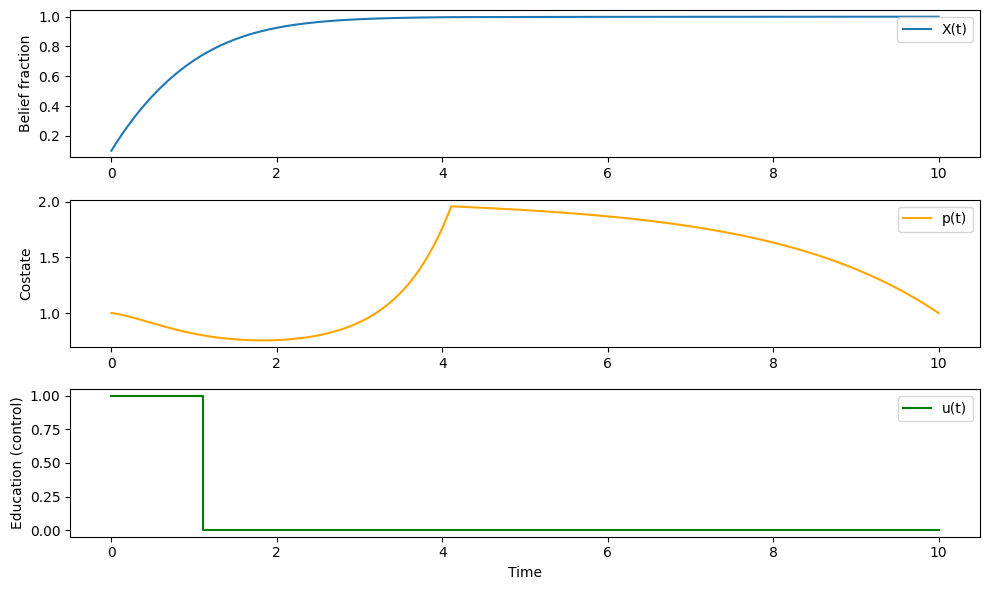

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
beta = 0.5
alpha = 2.0   # > 1
nu = 1.0

c = 0.2
u_max = 1.0

T = 10
N = 500
dt = T / N

t = np.linspace(0, T, N)

# =========================
# Initialize
# =========================
X = np.zeros(N)
p = np.zeros(N)
u = np.zeros(N)

# initial condition
X[0] = 0.1

# =========================
# Forward-Backward Sweep
# =========================
max_iter = 100
tol = 1e-4

for it in range(max_iter):
    X_old = X.copy()
    u_old = u.copy()

    # ---- Forward: state equation ----
    for i in range(N - 1):
        X[i+1] = X[i] + dt * ((beta * X[i]**alpha + u[i]) * (nu - X[i]))

    # ---- Backward: costate equation ----
    p[-1] = 1.0  # terminal condition

    for i in reversed(range(N - 1)):
        dH_dX = 1 + p[i+1] * (
            beta * alpha * X[i+1]**(alpha - 1) * (nu - X[i+1])
            - (beta * X[i+1]**alpha + u[i+1])
        )
        p[i] = p[i+1] + dt * dH_dX  # backward integration

    # ---- Update control (bang-bang) ----
    for i in range(N):
        if p[i] * (nu - X[i]) > c:
            u[i] = u_max
        else:
            u[i] = 0.0

    # ---- Convergence check ----
    if np.linalg.norm(X - X_old) < tol and np.linalg.norm(u - u_old) < tol:
        print(f"Converged in {it} iterations")
        break

# =========================
# Plot results
# =========================
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t, X, label="X(t)")
plt.ylabel("Belief fraction")
plt.legend()

plt.subplot(3,1,2)
plt.plot(t, p, label="p(t)", color="orange")
plt.ylabel("Costate")
plt.legend()

plt.subplot(3,1,3)
plt.step(t, u, label="u(t)", color="green")
plt.ylabel("Education (control)")
plt.xlabel("Time")
plt.legend()

plt.tight_layout()
plt.show()